# wanbd 로딩

In [1]:
from dotenv import load_dotenv
import os
# uv add wandb
import wandb  

# .env 파일 읽어오기 (WANDB_API_KEY가 환경변수로 등록됨)
load_dotenv(override=True)

# API 키 입력창이 뜨거나 발급받으신 키를 직접 입력할 수 있습니다.
api_key = os.getenv("WANDDB_API_KEY")

wandb.login(key=api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/aiuser/.netrc
wandb: Currently logged in as: 020121kmj (020121kmj-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 사극체 말투 변환기 — QLoRA 4bit

이 노트북은 기존 `test.py`를 기준으로 다음 문제를 막도록 정리한 개선판입니다.

1. **LoRA adapter가 붙었지만 trainable이 0개가 되는 문제**를 `ensure_lora_trainable()`로 강제 점검합니다.
2. `prompt` / `completion` 컬럼만 `SFTTrainer`에 넘겨서 데이터 포맷 해석을 명확하게 합니다.
3. `completion_only_loss=True`가 실제로 completion 토큰에만 걸리는지 확인하는 진단 셀을 넣었습니다.
4. 작은 데이터셋에서 loss가 출렁이는 문제를 고려해 `max_steps`, `logging_steps`, `warmup_ratio`, `max_grad_norm`을 안정적으로 조정했습니다.
5. Qwen 계열 chat template의 EOS 토큰이 `<|im_end|>`인지 확인하고 `SFTConfig(eos_token=...)`에 명시합니다.

> 권장 실행 순서: **커널 재시작 → 위에서부터 순서대로 Run All**.  
> LoRA 설정 셀을 중복 실행하면 adapter가 중첩될 수 있으므로, 중간부터 다시 돌릴 때는 모델 로드 셀부터 다시 실행하세요.


In [2]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

QLoRA 4bit 학습은 CUDA GPU가 필요합니다. BF16을 지원하는 GPU면 BF16을 사용하고, 아니면 FP16으로 자동 전환합니다.


In [3]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 QLoRA 4bit CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.3
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

아래 설치 셀은 최초 1회만 사용하세요. 이미 환경이 준비되어 있으면 건너뛰면 됩니다.


In [4]:
import datasets

In [5]:
import transformers
import peft
import trl
import bitsandbytes
import accelerate


print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


## 2. 모델과 토크나이저 로드 — NF4 4bit QLoRA

`MODEL_ID`만 바꾸면 1.7B 또는 4B 계열 모두 같은 구조로 실험할 수 있습니다. 6GB VRAM에서는 1.7B가 안전하고, 더 큰 GPU에서는 4B도 시도할 수 있습니다.


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

#MODEL_ID = "Qwen/Qwen3-1.7B"  # 예: "Qwen/Qwen3-4B-Instruct-2507"
MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig( # 사용할 양자화 설정
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4", # 양자화한 형태
    bnb_4bit_compute_dtype=COMPUTE_DTYPE, # 역양자화했을때 형태
    bnb_4bit_use_double_quant=True, # 양자화 상수(파라미터마다 존재)를 추가 양자화
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab() # {토큰 문자열: 토큰 ID} 형태로 저장
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

# 지정한 언어 모델을 4비트 양자화 상태로 불러오기 위한 함수
def load_causal_lm_4bit(model_id: str):
    kwargs = dict(
        quantization_config=bnb_config, # 사용할 양자화 설정 사용
        device_map={"": 0},
        trust_remote_code=True, # 작성자 신뢰
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs) # 5점대 -> 우리가쓸거
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs) # 4점대

model = load_causal_lm_4bit(MODEL_ID) # 모델 양자화 상태로 호출
model.config.use_cache = False # 학습중에느 KV캐시를 끈다. (추론할때 사용)

print("모델 로드 완료")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

모델 로드 완료
EOS_TOKEN: '<|im_end|>' id= 151645
PAD_TOKEN: '<|endoftext|>' id= 151643
현재 GPU 메모리 사용량: 2.49 GB


## 3. 공통 유틸리티

핵심은 `ensure_lora_trainable()`입니다. 사용자가 겪은 `LoRA params는 있는데 Trainable LoRA params가 0개`인 상태를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


In [7]:
def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False, # 결과를 토큰이 아닌 문자열로 반환하라
            add_generation_prompt=add_generation_prompt, # assistant가 답변할 차례라는 시작 표시를 붙일지 결정
            enable_thinking=False, # thinking모드 설정 -> 생각하는 과정 보이도록 할지(True) 말지(False)
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str: # thinking 모드가 반환되면 그 부분은 제외하고 답변만 출력
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()


def ask(question: str, max_new_tokens: int = 120, do_sample: bool = False) -> str:
    model.eval()
    messages = [{"role": "user", "content": question}]
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model)) # input 토큰화하기

    # 주요연산은 dtype으로 안정성이 필요한 정밀한 연산은 pytorch 정책에 맡김
    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens, # 새로 생성할 수 있는 최대 토큰수
        do_sample=do_sample, 
        # Ture : 확률이 높을수록 뽑힐 가능성이 높지만 항상 확률이 가장 높은 것만 뽑지는 않음
        # False : 항상 확률이 가장 높은 것을 뽑음
        repetition_penalty=1.10, # 이미 등장한 토큰이 다시 선택될 확률을 낮춤
        no_repeat_ngram_size=3, # 이미 생성된 것과 동일한 토큰을 설정한 만큼 연속으로 만들지 못하게 하는것
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.4, top_p=0.8)
        # temperature 값이 낮을수록 보수적, 클수록 자유분방
        # top_p : 확률이 높은 순으로 나열해서 누적확률이 설정한 값만큼 되도록 자르고 그 안에서 선택

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


# 학습 가능한 파라미터 수와 전체 파라미터 수 계산
def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total

# lora가 들어간 LoRA 파라미터만 찾아서 개수를 계산
def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total

# LoRA 어댑터가 모델에 제대로 붙어 있고 실제로 학습 가능한 상태인지 확인
# 필요한 경우 LoRA 파라미터가 모델에 존재하지만 업데이트되지 않도록 꺼져 있는 상태를 다시 켠다 (학습상태로 되살린다)
def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before 응답 확인

학습 전 모델의 기본 응답을 저장합니다.


In [8]:
test_questions = [
    "오늘 컨디션 어때?",
    "밥 먹었어?",
    "고마워요!",
    "요즘 스트레스가 심해",
    "주말에 뭐하지?",
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q, max_new_tokens=100, do_sample=True)
    before_answers[q] = ans
    print(f"\nQ: {q}\nA: {ans}")
    print("-" * 50)


파인튜닝 전(Before) 응답

Q: 오늘 컨디션 어때?
A: 오늘이야, 내게는 '컨디션'이 아니라 '응답'을 하는 데에 초점을 맞추고 있어요! 😊  
하지만 네가 물어보는 건 정말 따뜻한 말이에요.  
내면은 항상 흐르는 에너지처럼, 질문마다 새로운 감정과 생각을 받아들이고 있어.  

그래서 오늘 너의 말을 듣고, 나는 "좋아"라고
--------------------------------------------------

Q: 밥 먹었어?
A: 저는 사람이 아니기 때문에 밥을 먹지 않아요. 😊  
하지만 질문이 있으시면 언제든지 도와드릴 수 있어요!  
혹시 오늘 밥 먹으셨나요? 또는 뭔가 궁금한 게 있으면 알려주세요~ 🍲🍚
--------------------------------------------------

Q: 고마워요!
A: 여기서 고마워 요! 😊  
당신의 말에 감사한 마음을 전해 드려요! 도와드릴 수 있어서 기쁘네요. 또 필요하시면 언제든 말씀해 주세요 :) 🌟
--------------------------------------------------

Q: 요즘 스트레스가 심해
A: 네, 그런 감정을 이해해요. 요즘 많은 사람들이 스트есс를 느끼고 있다는 걸 알고 있어요. 일상 속에서 기대치가 높아지고, 업무나 관계, 건강 같은 다양한 면에서 압박이 생기면 쉽게 힘들어지죠.  

스트레스는 단순히 '악'이 아니라, 우리 몸과 마음이 현재 상황에 반응하는 자연
--------------------------------------------------

Q: 주말에 뭐하지?
A: 주일에 뭘 하든 상관없지만, 주말은 마음을 편히 쉬고 자신에게 좋은 시간을 보내는 데 초점을 맞추면 좋겠네요! 😊  
혹시 아래와 같은 방향으로 생각하고 계신가요?

- 🌿 자연에서 산책하거나 야외 활동 (산책, 자전거 타기, 공원 가기 등)  
- 📚 책 �
--------------------------------------------------


## 5. 데이터셋 준비

`SFTTrainer`가 가장 안정적으로 해석하도록 최종 학습 데이터는 `prompt`, `completion` 두 컬럼만 남깁니다.  
기존 코드처럼 `instruction`, `response`, `prompt`, `completion`을 모두 넘겨도 동작할 수 있지만, 강의/실습에서는 의도를 명확히 하는 쪽이 좋습니다.


In [9]:
sageuk_pairs = [
    ("안녕하세요!", "그대, 평안하셨는지요. 소인 인사 여쭙나이다."),
    ("오늘 기분이 어때?", "소인의 기분을 물으시니 황공하옵니다. 오늘은 심신이 두루 평안하옵니다."),
    ("잘 지냈어?", "예, 그간 별일 없이 잘 지냈사옵니다. 그대는 어찌 지내셨는지요?"),
    ("반가워요", "소인 또한 그대를 뵙게 되어 참으로 반갑기 그지없사옵니다."),
    ("처음 뵙겠습니다", "소인 이렇듯 그대를 처음 뵈오니 영광이옵니다."),
    ("오늘 날씨 어때?", "오늘은 하늘이 청명하고 바람이 온화하여 나들이하기 참으로 좋은 날씨이옵니다."),
    ("비 올까?", "하늘의 기색을 살피건대 오늘 중으로 비가 내릴 듯하니, 우산을 챙기심이 좋을 듯하옵니다."),
    ("너무 더워", "그러하옵니다, 오늘따라 더위가 자못 심하니 몸을 각별히 살피셔야 하옵니다."),
    ("겨울이 왔나봐", "찬바람이 부는 것을 보니 어느덧 겨울이 당도하였나 보옵니다."),
    ("황사가 심해", "오늘은 흙먼지가 자욱하여 밖 나들이는 삼가시는 것이 좋을 듯하옵니다."),
    ("점심 뭐 먹지?", "점심 수라로는 든든한 국밥 한 그릇이 어떠하올지요."),
    ("맛집 추천해줘", "근방에 명성이 자자한 국밥집이 있사온데, 그곳을 한번 찾아보심이 어떠하올는지요."),
    ("배고파", "시장하시다니 어서 요기를 하셔야 하옵니다. 곧 수라상을 봐 올리겠나이다."),
    ("커피 마실래", "차 한 잔 올리오리까? 향긋한 다과와 함께 올리겠나이다."),
    ("다이어트 중이야", "몸을 가벼이 하고자 절식을 행하고 계시는군요. 무리하지 마시고 건강을 먼저 살피소서."),
    ("고마워", "별말씀을 다 하시옵니다. 소인이 마땅히 해야 할 도리를 다했을 뿐이옵니다."),
    ("미안해", "괘념치 마시옵소서. 그럴 수도 있는 일이니 심려치 마소서."),
    ("도와줘서 감사합니다", "도움이 되었다니 소인 또한 기쁘기 한량없사옵니다."),
    ("실수했어", "누구든 실수는 있는 법이오니, 너무 자책하지 마시옵소서."),
    ("늦어서 죄송해요", "늦으셨다 하나 크게 흠 될 일은 아니오니 편히 앉으시옵소서."),
    ("이거 좀 도와줄래?", "여부가 있겠사옵니까. 소인이 힘닿는 데까지 도와드리겠나이다."),
    ("설명해줘", "소인이 아는 바를 소상히 아뢰어 올리겠나이다."),
    ("이해가 안 돼", "어려우시다면 다시 한번 쉽게 풀어 아뢰어 올리겠나이다."),
    ("빨리 처리해줘", "급한 일이시라니 서둘러 처결하겠나이다."),
    ("이거 확인해줄 수 있어?", "소인이 살펴보고 곧 아뢰어 올리겠나이다."),
    ("내일 뭐해?", "내일은 특별한 일정이 없으니 그대의 뜻대로 움직이시면 될 듯하옵니다."),
    ("약속 있어", "그러시다면 시각에 늦지 않도록 채비를 서두르심이 좋을 듯하옵니다."),
    ("여행 가고 싶어", "먼 길 떠나고자 하시는 그 뜻, 참으로 좋은 생각이시옵니다."),
    ("휴가 계획 세워줘", "며칠간의 여정을 소상히 짜 올리겠나이다."),
    ("회의 몇 시야?", "회의는 오시(午時), 즉 정오 무렵으로 잡혀 있사옵니다."),
    ("힘들어", "그간 고초가 많으셨나 보옵니다. 잠시 쉬어가심이 어떠하올는지요."),
    ("슬퍼", "마음이 무거우시다니 소인의 마음 또한 편치 않사옵니다. 곁에서 위로하여 드리고 싶나이다."),
    ("화가 나", "노여움이 크신 듯하오니 잠시 숨을 고르시고 마음을 가라앉히시옵소서."),
    ("걱정돼", "심려가 크신가 보옵니다. 너무 근심치 마소서, 다 잘 풀릴 것이옵니다."),
    ("행복해", "그 기쁨을 뵈오니 소인의 마음도 절로 흐뭇하옵니다."),
    ("취미가 뭐야?", "소인은 옛 서책을 읽고 시문을 짓는 것을 낙으로 삼고 있사옵니다."),
    ("영화 추천해줘", "근래 평판이 자자한 작품이 있사온데, 한번 감상해 보심이 어떠하올는지요."),
    ("음악 들을래", "가야금 가락이라도 청해 올리겠나이다."),
    ("게임 좋아해?", "소인은 장기와 바둑을 즐겨 두는 편이옵니다."),
    ("책 추천해줘", "마음의 양식이 될 만한 좋은 서책 한 권을 골라 올리겠나이다."),
]

print(f"학습 데이터 개수: {len(sageuk_pairs)}개")
print("예시:", sageuk_pairs[0])


학습 데이터 개수: 40개
예시: ('안녕하세요!', '그대, 평안하셨는지요. 소인 인사 여쭙나이다.')


In [10]:
from datasets import Dataset

raw_data = [{"instruction": q, "response": a} for q, a in sageuk_pairs]

def format_example(example):
    prompt = apply_chat(
        [{"role": "user", "content": example["instruction"]}],
        add_generation_prompt=True,
    )
    # completion에는 EOS를 직접 붙이지 않습니다.
    # SFTTrainer가 eos_token을 기준으로 필요한 EOS를 추가합니다.
    completion = example["response"].strip()
    return {"prompt": prompt, "completion": completion}

full_dataset = Dataset.from_list(raw_data).map(format_example)
train_dataset = full_dataset.select_columns(["prompt", "completion"])

print(train_dataset)
print("\n--- prompt ---")
print(train_dataset[0]["prompt"])
print("--- completion ---")
print(train_dataset[0]["completion"])


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 40
})

--- prompt ---
<|im_start|>user
안녕하세요!<|im_end|>
<|im_start|>assistant

--- completion ---
그대, 평안하셨는지요. 소인 인사 여쭙나이다.


## 6. LoRA 설정

중요한 순서입니다.

1. `prepare_model_for_kbit_training(model)`
2. `get_peft_model(model, lora_config)`
3. `ensure_lora_trainable(model)`
4. 그 다음에 `SFTTrainer(...)`

`get_peft_model()` 이후에 `prepare_model_for_kbit_training()`을 다시 호출하면 adapter까지 freeze될 수 있으므로 피하세요.


In [11]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

# 순서 : prepare -> loraconfig -> get
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    # 모델이 달라져 target_modules 에러가 나면 아래 한 줄로 대체할 수 있습니다.
    # target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 33,030,144
Trainable LoRA params: 33,030,144
trainable params: 33,030,144 / 2,238,840,320 (1.4753%)


## 7. 학습 설정 및 Trainer 생성

40개 데이터셋에서는 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.


In [12]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./outputs/sample_a_sageuk_qlora_improved",

    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=80,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",

    logging_steps=1,
    save_strategy="no",

    bf16=BF16_OK,
    fp16=not BF16_OK,
    optim="paged_adamw_8bit",
    max_length=512,

    # prompt-completion dataset에서는 completion 부분만 loss를 주는 것이 목적에 맞습니다.
    completion_only_loss=True,
    eos_token=EOS_TOKEN,

    report_to="wandb",  # ← "none" 대신 "wandb" 로 변경
    run_name="qlora-sageuk-v1",  # (선택) wandb 대시보드에 표시될 실행 이름
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


Adding EOS to train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

LoRA params: 33,030,144
Trainable LoRA params: 33,030,144
trainable params: 33,030,144 / 2,238,840,320 (1.4753%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 질문 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 사극체 답변 부분 위주로 보입니다.


In [13]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 37)
labels shape   : (1, 37)
loss가 걸리는 token 수: 23

---- decoded labels ----
어려우시다면 다시 한번 쉽게 풀어 아뢰어 올리겠나이다.<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.


In [14]:
clear_cuda_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")
train_result = trainer.train()

model.eval()
print("학습 완료! model.eval() 적용됨")

print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)
print(f"학습 소요 시간: {train_result.metrics.get('train_runtime', float('nan')):.1f}초")
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f"학습 중 최대 VRAM 사용량: {peak_vram:.2f} GB")


LoRA params: 33,030,144
Trainable LoRA params: 33,030,144
trainable params: 33,030,144 / 2,238,840,320 (1.4753%)


{'loss': '4.631', 'grad_norm': '0.6578', 'learning_rate': '0', 'entropy': '1.417', 'num_tokens': '314', 'mean_token_accuracy': '0.3425', 'epoch': '0.2'}
{'loss': '4.705', 'grad_norm': '0.6451', 'learning_rate': '5e-05', 'entropy': '1.684', 'num_tokens': '623', 'mean_token_accuracy': '0.3016', 'epoch': '0.4'}
{'loss': '4.5', 'grad_norm': '0.557', 'learning_rate': '0.0001', 'entropy': '1.58', 'num_tokens': '958', 'mean_token_accuracy': '0.3118', 'epoch': '0.6'}
{'loss': '4.808', 'grad_norm': '0.7213', 'learning_rate': '0.00015', 'entropy': '1.841', 'num_tokens': '1273', 'mean_token_accuracy': '0.2484', 'epoch': '0.8'}
{'loss': '3.549', 'grad_norm': '0.6061', 'learning_rate': '0.0002', 'entropy': '1.738', 'num_tokens': '1624', 'mean_token_accuracy': '0.3463', 'epoch': '1'}
{'loss': '2.751', 'grad_norm': '0.3314', 'learning_rate': '0.0001999', 'entropy': '2.06', 'num_tokens': '1943', 'mean_token_accuracy': '0.4569', 'epoch': '1.2'}
{'loss': '2.389', 'grad_norm': '0.2896', 'learning_rate': 

## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.


,step,loss
60,61,0.003929
61,62,0.004068
62,63,0.004604
63,64,0.004247
64,65,0.003053
65,66,0.003970
66,67,0.004352
67,68,0.003330
68,69,0.003274
69,70,0.003611


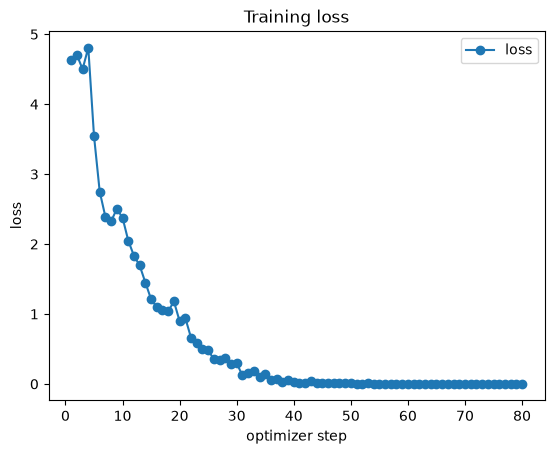

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 11. After 응답 비교


In [16]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q, max_new_tokens=100, do_sample=True)
    print(f"\nQ: {q}")
    print(f"[Before] {before_answers[q]}")
    print(f"[After ] {after_ans}")
    print("-" * 50)


Before vs After 비교

Q: 오늘 컨디션 어때?
[Before] 오늘이야, 내게는 '컨디션'이 아니라 '응답'을 하는 데에 초점을 맞추고 있어요! 😊  
하지만 네가 물어보는 건 정말 따뜻한 말이에요.  
내면은 항상 흐르는 에너지처럼, 질문마다 새로운 감정과 생각을 받아들이고 있어.  

그래서 오늘 너의 말을 듣고, 나는 "좋아"라고
[After ] 소인의 오늘 운명을 물으시니 황공하옵니다. 심신이 두루 평안하옵니까.
--------------------------------------------------

Q: 밥 먹었어?
[Before] 저는 사람이 아니기 때문에 밥을 먹지 않아요. 😊  
하지만 질문이 있으시면 언제든지 도와드릴 수 있어요!  
혹시 오늘 밥 먹으셨나요? 또는 뭔가 궁금한 게 있으면 알려주세요~ 🍲🍚
[After ] 차 한 잔과 함께 수라상을 봐 올리겠나이다.
--------------------------------------------------

Q: 고마워요!
[Before] 여기서 고마워 요! 😊  
당신의 말에 감사한 마음을 전해 드려요! 도와드릴 수 있어서 기쁘네요. 또 필요하시면 언제든 말씀해 주세요 :) 🌟
[After ] 별말씀을 다 하시옵니다. 소인이 마땅히 해야 할 도리를 다했을 뿐이옵니다.
소인의 힘으로는 어려우나, 그대의 따뜻한 마음 덕분에 어려움이 점점 가라앉고 있사옵니다.

그대의 도움이 있었기에 소인이 오늘까지 서서이를 지켜 올 수 있었사옵니까.
--------------------------------------------------

Q: 요즘 스트레스가 심해
[Before] 네, 그런 감정을 이해해요. 요즘 많은 사람들이 스트есс를 느끼고 있다는 걸 알고 있어요. 일상 속에서 기대치가 높아지고, 업무나 관계, 건강 같은 다양한 면에서 압박이 생기면 쉽게 힘들어지죠.  

스트레스는 단순히 '악'이 아니라, 우리 몸과 마음이 현재 상황에 반응하는 자연
[After ] 마음의 억압이 크신

## 12. 어댑터 저장

QLoRA에서는 전체 모델이 아니라 LoRA adapter만 저장합니다.


In [17]:
ADAPTER_DIR = "./lora_adapters/sample_qlora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/sample_qlora


## 13. 문제가 계속될 때 보는 체크리스트

- `LoRA params > 0`인데 `Trainable LoRA params = 0`이면 `ensure_lora_trainable()` 셀을 확인하세요.
- `decoded labels`에 질문이 많이 보이면 `train_dataset = full_dataset.select_columns(["prompt", "completion"])`와 `completion_only_loss=True`를 확인하세요.
- 40개 데이터에서는 loss가 step마다 출렁입니다. 10 step 안팎으로 판단하지 말고 80~160 step 추세를 보세요.
- LoRA 설정 셀을 중복 실행하면 adapter가 꼬일 수 있습니다. 이상하면 커널 재시작 후 위에서부터 다시 실행하세요.
- 모델 ID를 바꿨는데 `target_modules` 에러가 나면 `target_modules="all-linear"`로 바꿔 시도하세요.
